# CNN-LSTM Hybrid — Many-to-One Energy Price Forecasting

This notebook extends the earlier RNN/LSTM/GRU set with a **CNN-LSTM hybrid**:
a 1D convolution stage extracts local, position-independent temporal patterns
(short-lived spikes, ramps, daily-cycle edges) from the 24-hour input window,
then an LSTM models the longer-range dependencies across what the convolution
extracted, and a Dense layer produces the final forecast. Same dataset, same
many-to-one task (24h window -> next-hour price), same `FEATURE_COLS`/`TARGET_COL`
as `02_lstm_energy_forecasting.ipynb`, so results are directly comparable.

## 1. Why combine CNN and LSTM?

A plain LSTM reads the window one timestep at a time and must learn to notice
local patterns (like a sudden ramp in wind generation) purely through its
recurrent state. A **1D convolution** (`Conv1D`) instead slides a small filter
of width `KERNEL_SIZE` across the time axis, computing the same local pattern
detector at every position — exactly like a CNN's spatial filters, but along
time instead of space. This gives two practical benefits: (1) local patterns
are detected regardless of *where* in the window they occur (translation
invariance along time), and (2) `MaxPooling1D` then downsamples the sequence,
so the LSTM that follows has a *shorter*, pre-summarized sequence to reason
over — often easier to learn from than 24 raw timesteps.

The resulting pipeline is:

```
Input (24, 5) -> Conv1D + ReLU -> MaxPooling1D -> LSTM -> Dense(1) -> forecast
```

`padding="causal"` on the `Conv1D` layer matters for forecasting specifically:
it pads only on the left (past) side, so the filter centered at position *t*
never looks at position *t+1* or later — no future leakage into the features
the LSTM subsequently sees.

## 1b. Setup and Imports

Model architecture diagrams (`show_model_diagram`) need `pydot` and the Graphviz `dot` executable. If missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
sudo apt-get install graphviz   # Debian/Ubuntu
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

This is the same dataset and the same many-to-one task (24 hours of history ->
next-hour price) used in the companion `01_vanilla_rnn`, `02_lstm`, and
`03_gru` notebooks, so results here are directly comparable to those.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated).

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so
every cell in this notebook still runs end-to-end without the real file.

In [2]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"
TARGET_COLS = ["price actual", "total load actual"]


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset so the rest of "
              "the notebook still runs end-to-end.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

[info] Could not load the real Kaggle dataset (ModuleNotFoundError: No module named 'kagglehub').
[info] Falling back to a synthetic energy-like dataset so the rest of the notebook still runs end-to-end.
(3000, 5)


,total load actual,generation solar,generation wind onshore,generation fossil gas,price actual
time,,,,,
2018-01-01 00:00:00,26121.886832,187.353405,4635.070036,4584.255276,44.270897
2018-01-01 01:00:00,26619.500704,103.153828,4562.198944,4264.948320,47.950673
2018-01-01 02:00:00,28300.616808,294.919121,5206.577410,4379.785560,43.654361
2018-01-01 03:00:00,29205.307501,0.000000,5145.621944,4112.532146,45.508473
2018-01-01 04:00:00,28684.560185,0.000000,3082.747523,5431.236878,56.400750


In [3]:
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 3000   Range: 2018-01-01 00:00:00 -> 2018-05-05 23:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,3000.0,26012.466411,2975.575803,20148.011389,23364.934962,25988.117226,28674.494125,31850.097397
generation solar,3000.0,1141.780903,1337.615992,0.000000,0.000000,205.759112,2478.679081,3926.794159
generation wind onshore,3000.0,4497.836590,1415.426687,702.029260,3317.783483,4467.156718,5702.256882,8138.970495
generation fossil gas,3000.0,4300.230074,654.780603,2207.562638,3849.895831,4305.334437,4777.894254,6544.394789
price actual,3000.0,43.732220,8.036112,21.911996,37.781904,43.278355,49.695438,66.798140


## 3. Feature Engineering & Scaling

Chronological (non-shuffled) train/val/test split, scaler fit on the training
slice only — identical setup to the earlier notebooks.

In [4]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=2100  val=450  test=450  n_features=5


## 4. Windowing (Many-to-One)

Same task as the `many_to_one` section of the RNN/LSTM/GRU notebooks: a
24-hour window of all 5 features predicts the single next-hour price.
`X` shape `(n, WINDOW, N_FEATURES)`, `y` shape `(n, 1)`.

In [5]:
def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


WINDOW = 24
UNITS = 32          # LSTM units, kept equal to the earlier LSTM notebook for a fair comparison
FILTERS = 32        # Conv1D filters
KERNEL_SIZE = 3
POOL_SIZE = 2
EPOCHS = 100
BATCH_SIZE = 64

Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

X shape: (2076, 24, 5)  y shape: (2076, 1)


In [5]:
def make_many_to_one_multi(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single timestep with multiple target values."""
    values = data.values
    targets = data[TARGET_COLS].values  # Extract all target columns
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append(targets[t + window])    # Append the 2-vector target at t + window
    return np.array(X), np.array(y)

WINDOW = 24
UNITS = 32          # LSTM units, kept equal to the earlier LSTM notebook for a fair comparison
FILTERS = 32        # Conv1D filters
KERNEL_SIZE = 3
POOL_SIZE = 2
EPOCHS = 100
BATCH_SIZE = 64

Xm1, ym1 = make_many_to_one_multi(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one_multi(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

X shape: (2076, 24, 5)  y shape: (2076, 2)


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}

#
price_idx = FEATURE_COLS.index("price actual")
load_idx = FEATURE_COLS.index("total load actual")

price_min, price_max = scaler.data_min_[price_idx], scaler.data_max_[price_idx]
load_min, load_max = scaler.data_min_[load_idx], scaler.data_max_[load_idx]

def inverse_transform_targets(y_scaled: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Inverse transforms price and load independently using their respective min/max."""
    y_scaled = np.asarray(y_scaled)
    
    # y_scaled[:, 0] corresponds to 'price actual'
    # y_scaled[:, 1] corresponds to 'total load actual'
    price_unscaled = y_scaled[:, 0] * (price_max - price_min) + price_min
    load_unscaled = y_scaled[:, 1] * (load_max - load_min) + load_min
    
    return price_unscaled, load_unscaled

#_TARGET_MIN = scaler.data_min_[TARGET_IDX]
#_TARGET_MAX = scaler.data_max_[TARGET_IDX]


#def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
#    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Compiles with a fresh Adam optimizer, then fits. Use this for models
    that were NOT already compiled elsewhere (e.g. a plain baseline model)."""
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return fit_only(model, name, X_train, y_train, X_val, y_val, epochs)


def fit_only(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Fits a model that is ALREADY compiled (e.g. a Keras Tuner hypermodel,
    which is compiled with its own tuned optimizer/learning rate inside
    build_model() — recompiling it here would silently discard that tuning)."""
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    history_log[name] = history
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={history.history['val_mae'][-1]:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    # Unpack the tuple and extract price (or squeeze individual arrays if necessary)
    price_true, _ = inverse_transform_targets(y_true_scaled[:n_points])
    price_pred, _ = inverse_transform_targets(y_pred_scaled[:n_points])
    
    y_true = price_true.squeeze()
    y_pred = price_pred.squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
#     y_true = inverse_transform_targets(y_true_scaled[:n_points]).squeeze()
#     y_pred = inverse_transform_targets(y_pred_scaled[:n_points]).squeeze()

#     fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
#     axes[0].plot(y_true, label="true price")
#     axes[0].plot(y_pred, label="predicted price")
#     axes[0].set_title(f"{title} — forecast vs. actual")
#     axes[0].set_xlabel("hour (validation set)")
#     axes[0].set_ylabel("price (EUR/MWh)")
#     axes[0].legend()

#     axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
#     lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
#     axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
#     axes[1].set_title(f"{title} — predicted vs. actual")
#     axes[1].set_xlabel("actual price (EUR/MWh)")
#     axes[1].set_ylabel("predicted price (EUR/MWh)")
#     axes[1].legend()
#     plt.tight_layout()
#     plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_pipeline(stages, title, figsize=(11, 2.6)):
    """A left-to-right layer-pipeline illustration: one box per stage, with its
    output shape written underneath, connected by arrows. Unlike the recurrent
    'unrolled cells' diagrams in the RNN/LSTM/GRU notebooks, a CNN-LSTM is best
    pictured as a pipeline of stages rather than per-timestep cells."""
    n = len(stages)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 1.7, 0.8
    xs = [i * 2.3 for i in range(n)]

    for i, (label, shape, color) in enumerate(stages):
        x = xs[i]
        box = FancyBboxPatch(
            (x - box_w / 2, -box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, 0.12, label, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
        ax.text(x, -0.22, shape, ha="center", va="center", fontsize=7.5, color="white")
        if i < n - 1:
            ax.annotate("", xy=(xs[i + 1] - box_w / 2, 0), xytext=(x + box_w / 2, 0),
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4))

    ax.set_xlim(xs[0] - 1.3, xs[-1] + 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis("off")
    ax.set_title(title, fontsize=10.5)
    plt.tight_layout()
    plt.show()

## 5. Multivariate CNN-LSTM Model

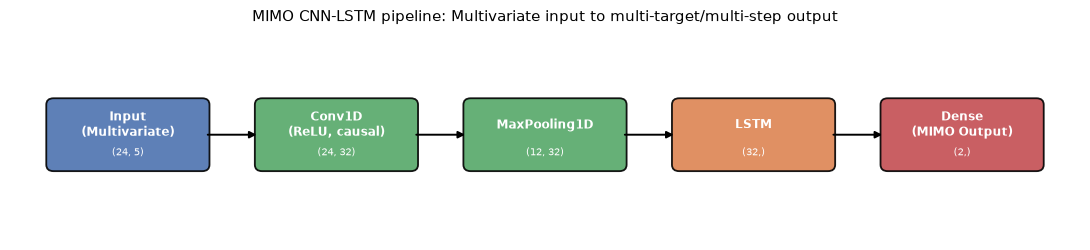

In [7]:
draw_pipeline(
    stages=[
        ("Input\n(Multivariate)", "(24, 5)", "#4C72B0"),
        ("Conv1D\n(ReLU, causal)", f"(24, {FILTERS})", "#55A868"),
        ("MaxPooling1D", f"(12, {FILTERS})", "#55A868"),
        ("LSTM", f"({UNITS},)", "#DD8452"),
        ("Dense\n(MIMO Output)", "(2,)", "#C44E52"),  # Updated from (1,) to (5,) for MIMO
    ],
    title="MIMO CNN-LSTM pipeline: Multivariate input to multi-target/multi-step output",
)

In [8]:
model_cnn_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation="relu", padding="causal"),
    tf.keras.layers.MaxPooling1D(pool_size=POOL_SIZE),
    tf.keras.layers.LSTM(UNITS, return_sequences=False),
    # --- Stack an additional Conv1D block before the LSTM: --------------------------
    #tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation="relu", padding="causal"),
   # tf.keras.layers.MaxPooling1D(pool_size=POOL_SIZE),
    # ---------------------------------------------------------------------------------
    tf.keras.layers.Dense(2),
], name="cnn_lstm_many_to_one")

model_cnn_lstm.summary()
show_model_diagram(model_cnn_lstm, "cnn_lstm_baseline.png")

Model: "cnn_lstm_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


Model: "cnn_lstm_B1_deeper_conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,002 (46.88 KB)

 Trainable params: 12,002 (46.88 KB)

 Non-trainable params: 0 (0.00 B)

cnn_lstm_B1_deeper_conv: ran 100/100 epochs  final val_loss=0.00531  val_mae=0.05470  params=12,002


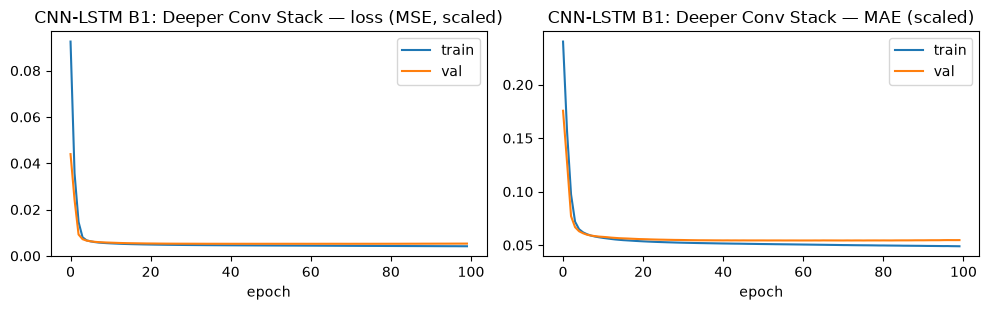

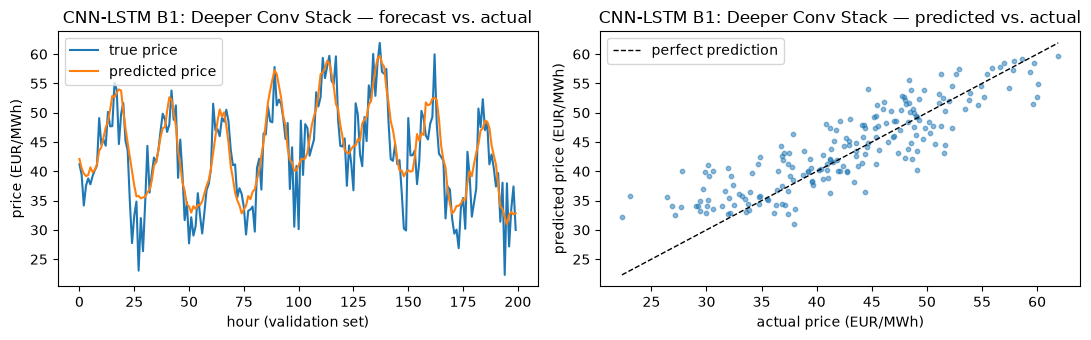

In [8]:
# ============================================================
# TASK B1 - DEEPEN THE CONV STACK
# Replace the original baseline model cell with this
# ============================================================

model_cnn_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),

    # Conv Block 1
    tf.keras.layers.Conv1D(
        filters=FILTERS,
        kernel_size=KERNEL_SIZE,
        activation="relu",
        padding="causal"
    ),
    tf.keras.layers.MaxPooling1D(
        pool_size=POOL_SIZE
    ),

    # Conv Block 2 (B1 change)
    tf.keras.layers.Conv1D(
        filters=FILTERS,
        kernel_size=KERNEL_SIZE,
        activation="relu",
        padding="causal"
    ),
    tf.keras.layers.MaxPooling1D(
        pool_size=POOL_SIZE
    ),

    # LSTM
    tf.keras.layers.LSTM(
        UNITS,
        return_sequences=False
    ),

    # Output
    tf.keras.layers.Dense(2)

], name="cnn_lstm_B1_deeper_conv")

model_cnn_lstm.summary()

hist_cnn_lstm = compile_and_fit(
    model_cnn_lstm,
    "cnn_lstm_B1_deeper_conv",
    Xm1,
    ym1,
    Xv_m1,
    yv_m1
)

plot_history(
    hist_cnn_lstm,
    "CNN-LSTM B1: Deeper Conv Stack"
)

pred = model_cnn_lstm.predict(
    Xv_m1,
    verbose=0
)

plot_point_prediction(
    yv_m1,
    pred,
    "CNN-LSTM B1: Deeper Conv Stack"
)

In [9]:
y_pred_val_scaled = model_cnn_lstm.predict(Xv_m1)

# Inverse transform both predictions and true values
price_true, load_true = inverse_transform_targets(yv_m1)
price_pred, load_pred = inverse_transform_targets(y_pred_val_scaled)

# Calculate MAE in original physical units
price_mae = np.mean(np.abs(price_true - price_pred))
load_mae = np.mean(np.abs(load_true - load_pred))

print(f"Validation Price MAE: {price_mae:.2f} EUR/MWh")
print(f"Validation Load MAE:  {load_mae:.2f} MW")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Validation Price MAE: 3.39 EUR/MWh
Validation Load MAE:  394.98 MW


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 1. Predictions on scaled validation data
y_pred_val_scaled = model_cnn_lstm.predict(Xv_m1)

# --- SCALED LOSSES (Loss during model training/optimization) ---
# yv_m1[:, 0] & y_pred_val_scaled[:, 0] -> Price (scaled)
# yv_m1[:, 1] & y_pred_val_scaled[:, 1] -> Load (scaled)

# Scaled MSE (matches Keras default 'mse' loss function)
val_loss_price_scaled_mse = np.mean((yv_m1[:, 0] - y_pred_val_scaled[:, 0]) ** 2)
val_loss_load_scaled_mse  = np.mean((yv_m1[:, 1] - y_pred_val_scaled[:, 1]) ** 2)

# Scaled MAE
val_loss_price_scaled_mae = np.mean(np.abs(yv_m1[:, 0] - y_pred_val_scaled[:, 0]))
val_loss_load_scaled_mae  = np.mean(np.abs(yv_m1[:, 1] - y_pred_val_scaled[:, 1]))


# --- UNSCALED LOSSES (Physical Units: EUR/MWh & MW) ---
# Inverse transform predictions and targets to original scale
price_true, load_true = inverse_transform_targets(yv_m1)
price_pred, load_pred = inverse_transform_targets(y_pred_val_scaled)

# Physical MAE
price_mae = mean_absolute_error(price_true, price_pred)
load_mae  = mean_absolute_error(load_true, load_pred)

# Physical MSE
price_mse = mean_squared_error(price_true, price_pred)
load_mse  = mean_squared_error(load_true, load_pred)

# Physical RMSE (Optional, useful for interpretation)
price_rmse = np.sqrt(price_mse)
load_rmse  = np.sqrt(load_mse)


# --- PRINT RESULTS ---
print("=== SCALED VALIDATION LOSSES ===")
print(f"Price Scaled MSE: {val_loss_price_scaled_mse:.6f}")
print(f"Load Scaled MSE:  {val_loss_load_scaled_mse:.6f}")
print(f"Price Scaled MAE: {val_loss_price_scaled_mae:.6f}")
print(f"Load Scaled MAE:  {val_loss_load_scaled_mae:.6f}\n")

print("=== PHYSICAL UNITS VALIDATION METRICS ===")
print(f"Validation Price MAE:  {price_mae:.2f} EUR/MWh")
print(f"Validation Price RMSE: {price_rmse:.2f} EUR/MWh")
print(f"Validation Load MAE:   {load_mae:.2f} MW")
print(f"Validation Load RMSE:  {load_rmse:.2f} MW")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== SCALED VALIDATION LOSSES ===
Price Scaled MSE: 0.008816
Load Scaled MSE:  0.001807
Price Scaled MAE: 0.075501
Load Scaled MAE:  0.033894

=== PHYSICAL UNITS VALIDATION METRICS ===
Validation Price MAE:  3.39 EUR/MWh
Validation Price RMSE: 4.21 EUR/MWh
Validation Load MAE:   394.98 MW
Validation Load RMSE:  495.42 MW


In [ ]:
hist_cnn_lstm = compile_and_fit(model_cnn_lstm, "cnn_lstm_baseline", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_cnn_lstm, "CNN-LSTM: baseline training")

pred = model_cnn_lstm.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "CNN-LSTM: baseline")

## 6. Compare Against the Plain LSTM Notebook

Open `02_lstm_energy_forecasting.ipynb` and find the printed line for its
`many_to_one` architecture (`ran 100/100 epochs ... params=... val_loss=...`).
Compare that against this notebook's `cnn_lstm_baseline` line above, on the
**same 24h-window -> next-hour-price task**:

- Which model has more parameters, and why (think about what `Conv1D` and
  `MaxPooling1D` add beyond a plain `LSTM` layer)?
- Which achieved the lower validation loss on your run? A hybrid isn't
  automatically better — on a dataset this size, whether the extra Conv1D
  stage helps depends on how much genuinely local, position-independent
  structure is actually present in the 24-hour window.

The companion notebook `05_cnn_lstm_optimized_energy_forecasting.ipynb` picks
up from here and searches over this model's hyperparameters automatically.